## Task 1: Design and implement supervised classification models using Logistic Regression, Linear Discriminant Analysis (LDA), and k-Nearest Neighbors (k-NN)
*Suggested Dataset: Iris Dataset*


In [16]:
import pandas as pd


In [17]:
from sklearn.datasets import load_iris


In [18]:
from sklearn.model_selection import train_test_split


In [19]:
from sklearn.preprocessing import StandardScaler


In [20]:
import warnings


In [21]:
warnings.filterwarnings("ignore")


In [22]:
# Load dataset


In [23]:
iris_raw = load_iris()


In [24]:
X_iris = iris_raw.data


In [25]:
y_iris = iris_raw.target


In [26]:
# Standardize features


In [27]:
scaler_iris = StandardScaler()


In [28]:
X_iris_scaled = scaler_iris.fit_transform(X_iris)


In [29]:
# Stratified train-test split (80% train, 20% test)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
     X_iris_scaled, y_iris, test_size=0.20, stratify=y_iris, random_state=42
)


In [31]:
print("Training set shape:", X_train.shape)


Training set shape: (120, 4)


In [32]:
print("Test set shape:", X_test.shape)


Test set shape: (30, 4)


### Subtask 1.2: Implementing Multinomial Logistic Regression
**Concept:** Design, train, and evaluate a multinomial Logistic Regression classifier to establish a parametric baseline model.


In [33]:
from sklearn.linear_model import LogisticRegression


In [34]:
from sklearn.metrics import accuracy_score


In [35]:
# Initialize multinomial Logistic Regression classifier


In [36]:
lr_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42)


In [37]:
lr_model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [38]:
# Predict on test data


In [39]:
lr_preds = lr_model.predict(X_test)


In [40]:
lr_accuracy = accuracy_score(y_test, lr_preds)


In [41]:
print(f"Logistic Regression Test Accuracy: {lr_accuracy * 100:.2f}%")


Logistic Regression Test Accuracy: 93.33%


### Subtask 1.3: Implementing Linear Discriminant Analysis (LDA)
**Concept:** Train a Linear Discriminant Analysis (LDA) classifier to observe how linear decision boundaries maximize the separation between different classes.


In [42]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


In [43]:
# Initialize LDA classifier


In [44]:
lda_model = LinearDiscriminantAnalysis()


In [45]:
lda_model.fit(X_train, y_train)


,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [46]:
# Predict on test data


In [47]:
lda_preds = lda_model.predict(X_test)


In [48]:
lda_accuracy = accuracy_score(y_test, lda_preds)


In [49]:
print(f"LDA Test Accuracy: {lda_accuracy * 100:.2f}%")


LDA Test Accuracy: 100.00%


### Subtask 1.4:  k-Nearest Neighbors (k-NN)
**Concept:** Train a k-NN classifier for classfication


In [50]:
# Import k-NN classifier


In [51]:
from sklearn.neighbors import KNeighborsClassifier


In [52]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [53]:
# Create the k-NN model


In [54]:
knn = KNeighborsClassifier()


In [55]:
# Train the model


In [56]:
knn.fit(X_train, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [57]:
# Make predictions


In [58]:
y_pred_knn = knn.predict(X_test)


In [59]:
# Evaluate the model


In [60]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)


In [62]:
print("k-NN Classification Accuracy:", knn_accuracy)


k-NN Classification Accuracy: 0.9333333333333333


### Subtask 1.5: Performance Comparison of Linear vs. Distance-Based Classifiers
**Concept:** Compare and analyze the test accuracy and structural differences of the Logistic Regression, LDA, and optimized k-NN models.


In [63]:
# Assemble performance metrics


In [67]:
comparison_df = pd.DataFrame({
        'Supervised Classifier': [
                    'Logistic Regression',
                    'Linear Discriminant Analysis (LDA)',
             'k-Nearest Neighbors (k-NN)'
                ],
        'Test Accuracy (%)': [
              lr_accuracy * 100,
                    lda_accuracy * 100,
                    knn_accuracy * 100
                ]
    })


In [68]:
print("--- Performance Comparison on Iris Dataset ---")


--- Performance Comparison on Iris Dataset ---


In [69]:
print(comparison_df.to_string(index=False))

             Supervised Classifier  Test Accuracy (%)
               Logistic Regression          93.333333
Linear Discriminant Analysis (LDA)         100.000000
        k-Nearest Neighbors (k-NN)          93.333333


## Task 2: Develop classification models using Naïve Bayes and Support Vector Machines (SVM) for complex classification tasks
*Suggested Dataset: Sonar Dataset*


### Subtask 2.1: Standard Scaling and High-Dimensional Data Splitting
**Concept:** Load the high-dimensional Sonar dataset, standardize the feature space, and perform a stratified split to prepare for binary classification.


In [70]:
import pandas as pd


In [71]:
from sklearn.model_selection import train_test_split


In [72]:
from sklearn.preprocessing import StandardScaler


In [73]:
# Load Sonar dataset


In [74]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"


In [75]:
sonar_features = [f"F_{i}" for i in range(1, 61)]


In [76]:
sonar_columns = sonar_features + ['Class']


In [77]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)


In [78]:
# Encode class: M -> 1, R -> 0


In [79]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})


In [80]:
X_sonar = sonar_df[sonar_features]


In [81]:
y_sonar = sonar_df['Class_numeric']


In [82]:
# Scale features


In [83]:
scaler_sonar = StandardScaler()


In [84]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)


In [85]:
# Split into train/test sets


In [87]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
    )




In [88]:
print("Sonar Training Set Shape:", X_train_s.shape)


Sonar Training Set Shape: (145, 60)


In [89]:
print("Sonar Test Set Shape:", X_test_s.shape)


Sonar Test Set Shape: (63, 60)


### Subtask 2.2: Implementing Gaussian Naïve Bayes
**Concept:** Train a Gaussian Naïve Bayes classifier to establish a probabilistic baseline under class-conditional independence assumptions.


In [90]:
from sklearn.naive_bayes import GaussianNB


In [91]:
from sklearn.metrics import accuracy_score


In [92]:
# Initialize and train Gaussian Naïve Bayes model


In [93]:
nb_model = GaussianNB()


In [94]:
nb_model.fit(X_train_s, y_train_s)


,priors,None
,var_smoothing,1e-09


In [95]:
# Predict and evaluate accuracy


In [96]:
nb_preds = nb_model.predict(X_test_s)


In [97]:
nb_accuracy = accuracy_score(y_test_s, nb_preds)


In [98]:
print(f"Gaussian Naïve Bayes Test Accuracy: {nb_accuracy * 100:.2f}%")


Gaussian Naïve Bayes Test Accuracy: 76.19%


### Subtask 2.3: Implementing Linear Support Vector Machines (SVM)
**Concept:** Train a Support Vector Machine (SVM) classifier with a linear kernel to construct a maximum-margin linear decision hyperplane.


In [99]:
from sklearn.svm import SVC


In [100]:
# Initialize and train Support Vector Classifier with Linear Kernel


In [101]:
svm_linear = SVC(kernel='linear', probability=True, random_state=42)


In [102]:
svm_linear.fit(X_train_s, y_train_s)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [103]:
# Predict and evaluate accuracy


In [104]:
linear_preds = svm_linear.predict(X_test_s)


In [105]:
linear_accuracy = accuracy_score(y_test_s, linear_preds)


In [106]:
print(f"Linear Kernel SVM Test Accuracy: {linear_accuracy * 100:.2f}%")


Linear Kernel SVM Test Accuracy: 79.37%


In [107]:
# Assemble performance metrics


In [110]:
sonar_comparison = pd.DataFrame({
        'Classifier': ['Gaussian Naïve Bayes (Probabilistic)', 'Linear Kernel SVM (Maximum-Margin)'],
        'Test Accuracy (%)': [nb_accuracy * 100, linear_accuracy * 100]
    })

In [111]:
print("--- Performance Comparison on High-Dimensional Sonar Dataset ---")


--- Performance Comparison on High-Dimensional Sonar Dataset ---


In [112]:
print(sonar_comparison.to_string(index=False))


                          Classifier  Test Accuracy (%)
Gaussian Naïve Bayes (Probabilistic)          76.190476
  Linear Kernel SVM (Maximum-Margin)          79.365079


## Task 3: Analyze model performance using confusion matrix, precision, recall, F1-score, ROC analysis, and cross-validation techniques.

### Subtask 3.1: Plotting the Confusion Matrix Heatmap
**Concept:** Generate a confusion matrix to visualize true positives, false positives, true negatives, and false negatives in your classification results.


In [113]:
import matplotlib.pyplot as plt


In [114]:
import seaborn as sns


In [115]:
from sklearn.metrics import confusion_matrix


In [116]:
# Compute confusion matrix on Logistic Regression predictions


In [117]:
cm = confusion_matrix(y_test, lr_preds)


In [118]:
# Plot confusion matrix using a Seaborn heatmap


In [119]:
plt.figure(figsize=(5, 4))


<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

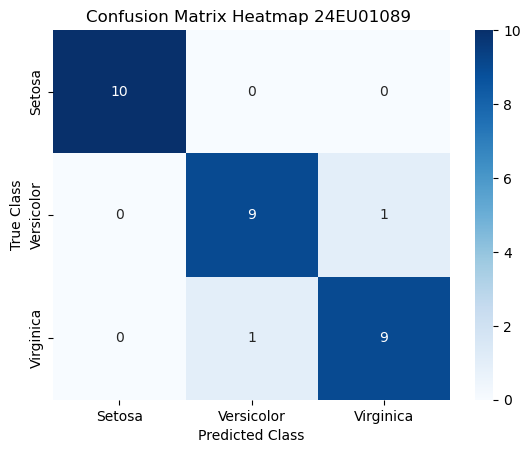

In [123]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Setosa', 'Versicolor', 'Virginica'],
    yticklabels=['Setosa', 'Versicolor', 'Virginica']
)

plt.title("Confusion Matrix Heatmap 24EU01089 ")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

### Subtask 3.2: Precision, Recall, F1-Score, and Support Analysis
**Concept:** Generate a detailed classification report to compute and analyze continuous performance metrics for both target classes.


In [124]:
from sklearn.metrics import classification_report


In [125]:
# Generate classification report for Logistic Regression


In [133]:
report_output = classification_report(
    y_test,
    lr_preds,
    target_names=['Setosa', 'Versicolor', 'Virginica']
)

print("--- Logistic Regression Classification Report ---")
print(report_output)

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [134]:
from sklearn.preprocessing import label_binarize


In [135]:
from sklearn.metrics import roc_curve, auc


In [136]:
import matplotlib.pyplot as plt


In [137]:
# Convert test labels to binary format


In [138]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])


In [139]:
# Get predicted probabilities


In [140]:
y_score = lr_model.predict_proba(X_test)


In [141]:
# Plot ROC curve for each class


In [142]:
plt.figure(figsize=(7,6))


<Figure size 700x600 with 0 Axes>

<Figure size 700x600 with 0 Axes>

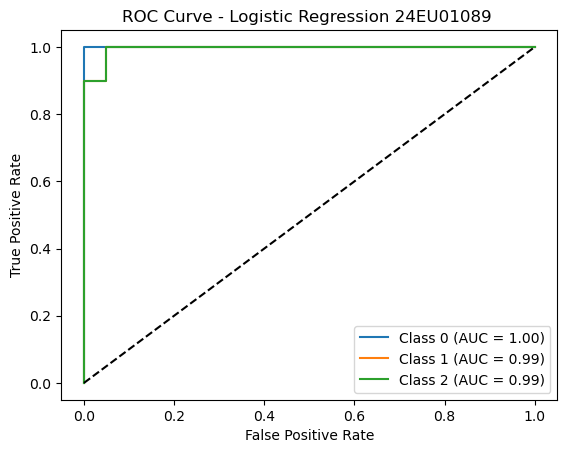

In [145]:
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression 24EU01089 ")
plt.legend(loc="lower right")
plt.show()

## Cross Validation

In [146]:
from sklearn.datasets import load_iris


In [147]:
from sklearn.preprocessing import StandardScaler


In [148]:
from sklearn.linear_model import LogisticRegression


In [149]:
from sklearn.model_selection import cross_val_score


In [150]:
import numpy as np


In [151]:
# Load the Iris dataset


In [152]:
iris = load_iris()


In [153]:
X = iris.data


In [154]:
y = iris.target


In [155]:
# Standardize the features


In [156]:
scaler = StandardScaler()


In [157]:
X_scaled = scaler.fit_transform(X)


In [158]:
# Create Logistic Regression model


In [159]:
lr_model = LogisticRegression(max_iter=200)


In [162]:
# Perform 5-fold Cross Validation
cv_scores = cross_val_score(
    lr_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores: [0.96666667 1.         0.93333333 0.9        1.        ]
Mean Accuracy: 0.9600000000000002
Standard Deviation: 0.038873012632301994


In [163]:
# Display results


In [166]:

print("5-Fold Cross-Validation Accuracy:")

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean Accuracy: {:.2f}%".format(np.mean(cv_scores) * 100))
print("Standard Deviation: {:.2f}%".format(np.std(cv_scores) * 100))

5-Fold Cross-Validation Accuracy:
Fold 1: 0.9667
Fold 2: 1.0000
Fold 3: 0.9333
Fold 4: 0.9000
Fold 5: 1.0000

Mean Accuracy: 96.00%
Standard Deviation: 3.89%
